In [1]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
import numpy as np

In [2]:
datos = "documentos_udea_2004_2024.xlsx"
df = pd.read_excel(datos)
df.head(10)

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
0,ACTAS,0198,2004/12/14,NaN,NaN,NaN,NaN
1,ACTAS,0283,2004/12/09,NaN,NaN,NaN,NaN
2,ACTAS,0282,2004/12/02,NaN,NaN,NaN,NaN
3,ACTAS,0280,2004/11/18,NaN,NaN,NaN,NaN
4,ACTAS,0279,2004/11/11,NaN,NaN,NaN,NaN
5,ACTAS,0197,2004/11/09,NaN,NaN,NaN,NaN
6,ACTAS,0278,2004/11/04,NaN,NaN,NaN,NaN
7,ACTAS,0277,2004/11/02,NaN,NaN,NaN,NaN
8,ACTAS,0276,2004/10/21,NaN,NaN,NaN,NaN
9,ACTAS,0196,2004/10/12,NaN,NaN,NaN,NaN


In [3]:
df.tail(10)

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
26028,RESOLUCIONES,50939,2024/01/19,NaN,NORMATIVA.UDEA.EDU.CO,FIJAR LOS DERECHOS DE MATRÍCULA Y COMPLEMENTAR...,NaN
26029,RESOLUCIONES,50949,2024/01/19,NaN,NORMATIVA.UDEA.EDU.CO,TRASLADAR LA PLAZA NO 887 DEL DEPARTAMENTO DE ...,NaN
26030,RESOLUCIONES,50941,2024/01/19,NaN,NORMATIVA.UDEA.EDU.CO,ACEPTAR LA RENUNCIA PRESENTADA POR LA SEÑORA N...,NaN
26031,RESOLUCIONES,50940,2024/01/19,NaN,NORMATIVA.UDEA.EDU.CO,ACEPTAR LA RENUNCIA PRESENTADA POR EL SEÑOR HA...,NaN
26032,RESOLUCIONES,50944,2024/01/19,NaN,NORMATIVA.UDEA.EDU.CO,COMISIONAR Y NOMBRAR AL SEÑOR JULIO EDUARDO HO...,NaN
26033,RESOLUCIONES,50948,2024/01/19,2024/01/19,NORMATIVA.UDEA.EDU.CO,ESTABLECER LINEAMIENTOS PARA LA IMPLEMENTACIÓN...,NaN
26034,RESOLUCIONES,50937,2024/01/17,NaN,NORMATIVA.UDEA.EDU.CO,MODIFICAR EL ARTÍCULO 1 DE LA RESOLUCIÓN RECTO...,RESOLUCION RECTORAL 50835 DEL 27 DE NOVIEMBRE ...
26035,RESOLUCIONES,50936,2024/01/17,NaN,NORMATIVA.UDEA.EDU.CO,CONCEDER COMISIÓN DE SERVICIOS A LA SEÑORA NAT...,NaN
26036,RESOLUCIONES,50938,2024/01/17,NaN,NORMATIVA.UDEA.EDU.CO,CONCEDER COMISIÓN DE SERVICIOS AL SEÑOR GABRIE...,NaN
26037,RESOLUCIONES,50934,2024/01/17,NaN,NORMATIVA.UDEA.EDU.CO,PRORROGAR LA COMISÓN ADMINISTRATIVA DE LA SEÑO...,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26038 entries, 0 to 26037
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   tipo_documento       26038 non-null  str  
 1   numero               26038 non-null  str  
 2   fecha_expedicion     26038 non-null  str  
 3   entrada_vigencia     1555 non-null   str  
 4   medio_publicacion    21845 non-null  str  
 5   resuelve             25065 non-null  str  
 6   normas_relacionadas  2315 non-null   str  
dtypes: str(7)
memory usage: 1.4 MB


In [5]:
df.shape

(26038, 7)

In [6]:
df.duplicated().sum()

np.int64(1034)

In [7]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           0
entrada_vigencia       24483
medio_publicacion       4193
resuelve                 973
normas_relacionadas    23723
dtype: int64

In [8]:
nulos_por_tipo_documento = df.groupby('tipo_documento')['resuelve'].apply(lambda x: x.isnull().sum())
print("Cantidad de valores nulos en la columna 'resuelve' por tipo de documento:")
print(nulos_por_tipo_documento)

Cantidad de valores nulos en la columna 'resuelve' por tipo de documento:
tipo_documento
ACTAS           972
ACUERDOS          0
RESOLUCIONES      1
Name: resuelve, dtype: int64


In [9]:
cantidad_actas = df[df['tipo_documento'] == 'ACTAS'].shape[0]
print(f"Cantidad total de documentos del tipo 'ACTAS': {cantidad_actas}")

Cantidad total de documentos del tipo 'ACTAS': 1119


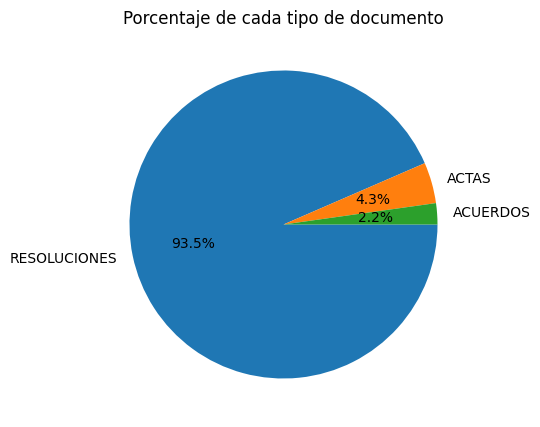

In [10]:
porcentaje_por_tipo_documento = df['tipo_documento'].value_counts(normalize=True) * 100
#grafico
porcentaje_por_tipo_documento.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 5),
    counterclock=False,
)
plt.title('Porcentaje de cada tipo de documento')
plt.ylabel('')
plt.show()

#print("Porcentaje de cada tipo de documento:")
#print(porcentaje_por_tipo_documento)

In [11]:
#mostrar solo la columna 'resuelve' de las 10 primeras actas que no tienen valor nulo en la columna 'resuelve'
actas_sin_nulos = df[(df['tipo_documento'] == 'ACTAS') & (df['resuelve'].notnull())]
print("Las 10 primeras actas sin valores nulos en la columna 'resuelve':")
print(actas_sin_nulos.head(10)['resuelve'])

Las 10 primeras actas sin valores nulos en la columna 'resuelve':
333    APROBACION ACTAS 619 Y 620 INFORME VICERRECTOR...
338    APROBACION ACTA 618 INFORME VICERRECTORIA INFO...
339    INFORME JURADOS CONVOCATORIA ESTRATEGIA DE SOS...
341    APROBACION ACTA 616 INFORME VICERRECTORIA DE I...
344    BALANCE DE AUTOEVALUACION EN AUDITORIO PRINCIP...
347    APROBACION ACTAS 614 Y 615 INFORME VICERRECTOR...
354    APROBACION ACTA 613 INFORME VICERRECTORIA PREM...
356    TERMINOS DE REFERENCIA ESTRATEGIA SOSTENIBILID...
358    APROBACION ACTA 612 INFORME VICERRECTORIA FOND...
361    APROBACION ACTA 610 Y 611 INFORME VICERRECTORI...
Name: resuelve, dtype: str


In [12]:
df_actas = df.loc[df['tipo_documento'] == 'ACTAS']
df_actas.to_excel("actas.xlsx", index=False)

In [13]:
#Eliminar todas las actas del dataframe
print("Antes:", df['tipo_documento'].value_counts())

df = df[df['tipo_documento'].str.strip().str.upper() != 'ACTAS']

print("Después:", df['tipo_documento'].value_counts())

Antes: tipo_documento
RESOLUCIONES    24341
ACTAS            1119
ACUERDOS          578
Name: count, dtype: int64
Después: tipo_documento
RESOLUCIONES    24341
ACUERDOS          578
Name: count, dtype: int64


In [14]:
df.shape

(24919, 7)

In [15]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           0
entrada_vigencia       23364
medio_publicacion       3550
resuelve                   1
normas_relacionadas    22604
dtype: int64

In [16]:
antes = df['entrada_vigencia'].copy()
df['entrada_vigencia'] =pd.to_datetime(
    df['entrada_vigencia'],
    format='mixed',
    errors='coerce'
)


In [17]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           0
entrada_vigencia       23366
medio_publicacion       3550
resuelve                   1
normas_relacionadas    22604
dtype: int64

In [18]:
cambiaron = antes.notna() & df['entrada_vigencia'].isna()

In [19]:
df.iloc[cambiaron]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
12753,RESOLUCIONES,2950,2015/09/28,NaT,NORMATIVA.UDEA.EDU.CO,AUTORIZAR LA CONVOCATORIA Y FIJAR REQUISITOS D...,NaN
20949,RESOLUCIONES,47233,2020/08/21,NaT,NORMATIVA.UDEA.EDU.CO,ESTABLECEN LOS LINEAMIENTOS PARA LA ENTREGA DE...,NaN


In [20]:
antes[cambiaron]

12753     2015/2016
20949    2020/28/21
Name: entrada_vigencia, dtype: str

In [21]:
df.loc[20949, 'entrada_vigencia'] = pd.to_datetime('2020/08/21')
df.loc[12753, 'entrada_vigencia'] = pd.to_datetime('2015/09/28')

In [22]:
df.loc[[12753,20949]]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
12753,RESOLUCIONES,2950,2015/09/28,2015-09-28,NORMATIVA.UDEA.EDU.CO,AUTORIZAR LA CONVOCATORIA Y FIJAR REQUISITOS D...,NaN
20949,RESOLUCIONES,47233,2020/08/21,2020-08-21,NORMATIVA.UDEA.EDU.CO,ESTABLECEN LOS LINEAMIENTOS PARA LA ENTREGA DE...,NaN


In [23]:
antes_expedicion = df['fecha_expedicion'].copy()
df['fecha_expedicion'] = pd.to_datetime(
    df['fecha_expedicion'],
    format='mixed',
    errors='coerce'
)

In [24]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           1
entrada_vigencia       23364
medio_publicacion       3550
resuelve                   1
normas_relacionadas    22604
dtype: int64

In [25]:
cambiaron_expedicion = antes_expedicion.notna() & df['fecha_expedicion'].isna()

In [26]:
df.iloc[cambiaron_expedicion]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
15610,RESOLUCIONES,9619,NaT,NaT,NaN,CONCEDER DEDICACION EXCLUSIVA A ADRIANA MARIA ...,NaN


In [27]:
antes_expedicion[cambiaron_expedicion] # la 15610 es 2016/04/07

15610    2016/04/0
Name: fecha_expedicion, dtype: str

In [28]:
df.loc[15610, 'fecha_expedicion'] = pd.to_datetime('2016/04/07')

In [29]:
df.loc[[15610]]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
15610,RESOLUCIONES,9619,2016-04-07,NaT,NaN,CONCEDER DEDICACION EXCLUSIVA A ADRIANA MARIA ...,NaN


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24919 entries, 1119 to 26037
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tipo_documento       24919 non-null  str           
 1   numero               24919 non-null  str           
 2   fecha_expedicion     24919 non-null  datetime64[us]
 3   entrada_vigencia     1555 non-null   datetime64[us]
 4   medio_publicacion    21369 non-null  str           
 5   resuelve             24918 non-null  str           
 6   normas_relacionadas  2315 non-null   str           
dtypes: datetime64[us](2), str(5)
memory usage: 1.3 MB


In [31]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           0
entrada_vigencia       23364
medio_publicacion       3550
resuelve                   1
normas_relacionadas    22604
dtype: int64

In [32]:
#identificar la fila que tiene un valor nulo en 'resuelve'
df[df['resuelve'].isnull()]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
11753,RESOLUCIONES,8027,2014-05-09,NaT,NaN,NaN,NaN


In [33]:
df.loc[11753, 'resuelve'] = 'CONCEDER DEDICACION EXCLUSIVA A SERGIO AGUDELO FLOREZ PROFESOR DE LA FACULTAD DE INGENIERIA'

In [34]:
df.isnull().sum()

tipo_documento             0
numero                     0
fecha_expedicion           0
entrada_vigencia       23364
medio_publicacion       3550
resuelve                   0
normas_relacionadas    22604
dtype: int64

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24919 entries, 1119 to 26037
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tipo_documento       24919 non-null  str           
 1   numero               24919 non-null  str           
 2   fecha_expedicion     24919 non-null  datetime64[us]
 3   entrada_vigencia     1555 non-null   datetime64[us]
 4   medio_publicacion    21369 non-null  str           
 5   resuelve             24919 non-null  str           
 6   normas_relacionadas  2315 non-null   str           
dtypes: datetime64[us](2), str(5)
memory usage: 1.3 MB


In [36]:
df.duplicated().sum()

np.int64(1013)

In [37]:
df.loc[df.duplicated(keep=False)]

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas
1795,RESOLUCIONES,19968,2004-11-25,NaT,NORMATIVA.UDEA.EDU.CO,ASIGNAR A MARGARITA MARIA RESTREPO GARAY JEFE ...,NaN
1796,RESOLUCIONES,19964,2004-11-25,NaT,NORMATIVA.UDEA.EDU.CO,PRORROGAR COMISION ADMINISTRATIVA A LUIS ALBER...,NaN
1800,RESOLUCIONES,19968,2004-11-25,NaT,NORMATIVA.UDEA.EDU.CO,ASIGNAR A MARGARITA MARIA RESTREPO GARAY JEFE ...,NaN
1801,RESOLUCIONES,19964,2004-11-25,NaT,NORMATIVA.UDEA.EDU.CO,PRORROGAR COMISION ADMINISTRATIVA A LUIS ALBER...,NaN
1896,RESOLUCIONES,19800,2004-10-21,NaT,NORMATIVA.UDEA.EDU.CO,COMISIONAR A URIEL LOZANO RIVEARA PROFESOR ESC...,RESOLUCION RECTORAL 19836 DEL 20 DE SEPTIEMBRE...
...,...,...,...,...,...,...,...
25770,RESOLUCIONES,51210,2024-05-02,NaT,NORMATIVA.UDEA.EDU.CO,AUTORIZAR EL DUPLICADO DEL DIPLOMA DE GRADO A ...,NaN
25809,RESOLUCIONES,51163,2024-04-10,NaT,NORMATIVA.UDEA.EDU.CO,ACEPTAR LA RENUNCIA PRESENTADA POR EL SENOR CE...,NaN
25810,RESOLUCIONES,51167,2024-04-10,NaT,NORMATIVA.UDEA.EDU.CO,ASIGNAR RECURSOS EN LA VIGENCIA 2024 PROVENIEN...,NaN
25812,RESOLUCIONES,51163,2024-04-10,NaT,NORMATIVA.UDEA.EDU.CO,ACEPTAR LA RENUNCIA PRESENTADA POR EL SENOR CE...,NaN


In [38]:
df.loc[[25810,25813]].T

,25810,25813
tipo_documento,RESOLUCIONES,RESOLUCIONES
numero,51167,51167
fecha_expedicion,2024-04-10 00:00:00,2024-04-10 00:00:00
entrada_vigencia,NaT,NaT
medio_publicacion,NORMATIVA.UDEA.EDU.CO,NORMATIVA.UDEA.EDU.CO
resuelve,ASIGNAR RECURSOS EN LA VIGENCIA 2024 PROVENIEN...,ASIGNAR RECURSOS EN LA VIGENCIA 2024 PROVENIEN...
normas_relacionadas,NaN,NaN


In [39]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [40]:
df.dtypes

tipo_documento                    str
numero                            str
fecha_expedicion       datetime64[us]
entrada_vigencia       datetime64[us]
medio_publicacion                 str
resuelve                          str
normas_relacionadas               str
dtype: object

In [41]:
df.shape

(23906, 7)

In [42]:
df.columns

Index(['tipo_documento', 'numero', 'fecha_expedicion', 'entrada_vigencia',
       'medio_publicacion', 'resuelve', 'normas_relacionadas'],
      dtype='str')

In [43]:
df_original = df.copy()

In [44]:
columnas_categoricas = ['tipo_documento', 'medio_publicacion', 'resuelve', 'normas_relacionadas']
for colu in columnas_categoricas:
    df[colu] = (
        df[colu]
        .str.strip() # elimina espacios al inicio y al final
        .str.lower() # pone todo en minúscula
        .str.replace(r"[^0-9a-záéíóúüñ\s]+", " ", regex=True) # Elimina caracteres especiales, dejando solo letras, números y espacios
        .str.replace(r'\s+', ' ', regex=True) # Elimina espacios extra entre palabras
    )

In [45]:
resumen = pd.DataFrame({
    
    'columna': columnas_categoricas,

    # registros que tenían al menos una mayúscula
    'registros_con_mayusculas': [
        df_original[c].str.contains(r'[A-ZÁÉÍÓÚÜÑ]', na=False).sum()
        for c in columnas_categoricas
    ],

    # registros que cambiaron después de la limpieza completa
    'registros_modificados': [
        (df_original[c] != df[c]).sum()
        for c in columnas_categoricas
    ]

})

# Mostrar resultado
print(resumen)

               columna  registros_con_mayusculas  registros_modificados
0       tipo_documento                     23906                  23906
1    medio_publicacion                     20460                  23906
2             resuelve                     23906                  23906
3  normas_relacionadas                      2231                  23906


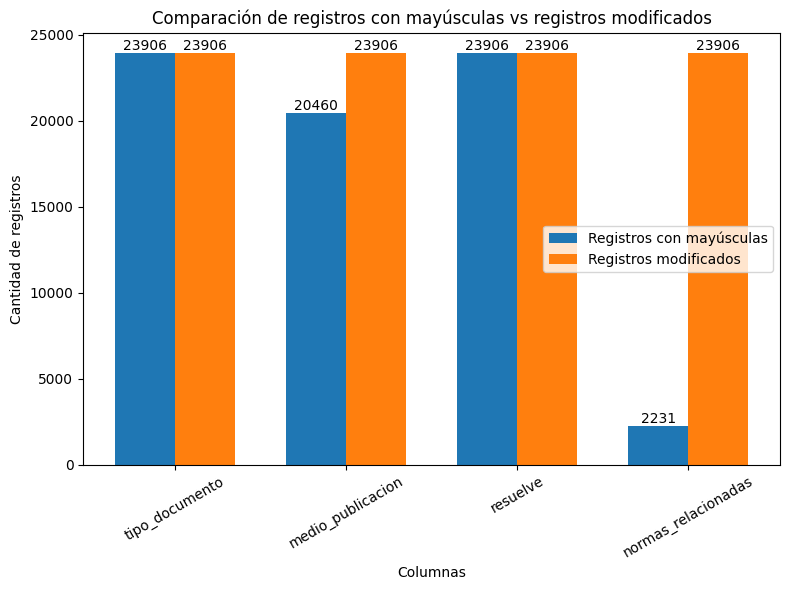

In [46]:
# Datos
columnas = resumen['columna']
antes = resumen['registros_con_mayusculas']
modificados = resumen['registros_modificados']

# Posiciones de las barras
x = np.arange(len(columnas))
ancho = 0.35

# Crear figura
plt.figure(figsize=(8,6))

# Barras
barras1 = plt.bar(x - ancho/2, antes, ancho, label='Registros con mayúsculas')
barras2 = plt.bar(x + ancho/2, modificados, ancho, label='Registros modificados')

# Etiquetas
plt.xlabel('Columnas')
plt.ylabel('Cantidad de registros')
plt.title('Comparación de registros con mayúsculas vs registros modificados')
plt.xticks(x, columnas, rotation=30)

# Leyenda
plt.legend()

# Agregar valores encima de cada barra
for barra in barras1:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{int(altura)}',
        ha='center',
        va='bottom'
    )

for barra in barras2:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{int(altura)}',
        ha='center',
        va='bottom'
    )

# Ajustar diseño
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [47]:
df["resuelve_tokens"] = (
    df["resuelve"]
    .fillna("")
    .str.findall(r"[a-záéíóúüñ]+")
)

In [48]:
df[['resuelve', 'resuelve_tokens']].head(5)

,resuelve,resuelve_tokens
1119,modificar acuerdo superior 223 del 4 de junio ...,"[modificar, acuerdo, superior, del, de, junio,..."
1120,aprobar presupuesto fondos generales vigencia ...,"[aprobar, presupuesto, fondos, generales, vige..."
1121,aprobar presupuesto fondos seguridad social vi...,"[aprobar, presupuesto, fondos, seguridad, soci..."
1122,aprobar presupuesto fondo bienestar universita...,"[aprobar, presupuesto, fondo, bienestar, unive..."
1123,modificar articulos 45 66 y 74 del acuerdo sup...,"[modificar, articulos, y, del, acuerdo, superi..."


In [49]:
#nltk.download('stopwords')

def eliminar_stopwords_en_columna(
    df,
    col="resuelve_tokens",
    idioma="spanish",
    extras=None,
    conservar=None,
    nombres_ruido=None,
    tokens_basura=None,
    variantes_ruido=None
):
    stop = set(stopwords.words(idioma))

    if extras:
        stop |= set(extras)

    if conservar:
        stop -= set(conservar)

    if nombres_ruido is None:
        nombres_ruido = set()
    else:
        nombres_ruido = set(nombres_ruido)

    if tokens_basura is None:
        tokens_basura = set()
    else:
        tokens_basura = set(tokens_basura)

    if variantes_ruido is None:
        variantes_ruido = set()
    else:
        variantes_ruido = set(variantes_ruido)

    def filtrar(toks):
        if toks is None:
            return []

        if not isinstance(toks, list):
            return []

        return [
            t for t in toks
            if t
            and t not in stop
            and t not in nombres_ruido
            and t not in tokens_basura
            and t not in variantes_ruido
        ]

    df[col] = df[col].apply(filtrar)

    return df

# RUIDO DEL DOMINIO / ESTRUCTURAL / ADMINISTRATIVO

extras = {
    # normativo / estructural
    "articulo", "art", "paragrafo", "numeral", "inciso", "literal",
    "resolucion", "rectoral", "acuerdo", "resuelve", "comuniquese",
    "publiquese", "cumplase", "acta", "actas", "informe", "informes",
    "presentacion", "respuesta", "version", "final", "segunda",
    "inicio", "cierre", "identificados", "varios",

    # administrativo / identidad
    "cedula", "cédula", "ciudadania", "ciudadanía", "cuidadanía",
    "cc", "nombre", "apellidos", "identificada", "identificado",

    # organizacional / institucional
    "facultad", "departamento", "universidad", "escuela",
    "adscrita", "adscrito", "administrativa", "administrativo",
    "profesional", "grado", "antioquia", "vicerrectoria",
    "rectoria", "superior", "universitario", "universitaria",
    "institucion", "institucional", "consejo", "representante",

    # procedimental / general
    "procedimiento", "fecha", "proceso", "plaza", "temporal",
    "tiempo", "completo", "partir", "diploma", "auxiliar", "instituto",

    # cargos / fórmulas frecuentes
    "docente", "profesor", "profesora", "jefe", "secretaria",
    "coordinador", "señora", "señor", "cargo",

    # formularias
    "presentada", "presentado",

    # meses / tiempo
    "enero", "febrero", "marzo", "abril", "mayo", "junio",
    "julio", "agosto", "septiembre", "setiembre", "octubre",
    "noviembre", "diciembre", "año"
}

# PALABRAS A CONSERVAR

conservar = {"no", "ni", "sin", "pero"}

# NOMBRES Y APELLIDOS FRECUENTES QUE GENERAN RUIDO


nombres_ruido = {
    # nombres
    "maria", "juan", "jose", "carlos", "luis", "ana", "andres",
    "fernando", "dario", "alberto", "francisco", "antonio",
    "patricia", "gabriel", "victor", "claudia", "elena",
    "mauricio", "pablo", "camilo", "natalia", "diana",
    "gloria", "oscar", "paula", "jorge", "david", "amparo",
    "hernan", "william", "mary", "luz", "beatriz", "martha",
    "santiago", "olga", "victoria", "cecilia", "daniel",
    "sergio", "javier", "eduardo", "alfredo", "bertha", "andrea",
    "isabel", "adriana",

    # apellidos
    "gomez", "restrepo", "lopez", "rodriguez", "garcia",
    "martinez", "ramirez", "cardona", "velez", "jimenez",
    "arango", "duque", "bedoya", "patiño", "castaño",
    "giraldo", "ruiz", "valencia", "aguirre", "lopera",
    "salazar", "mejia", "ospina", "vasco", "upegui",
    "mondragon", "fernandez", "naranjo", "holguin",
    "escobar", "villegas", "hernandez", "zapata",
    "gallego", "rocha", "quintero", "gaviria", "cano",
    "franco", "muñoz", "agudelo", "florez", "flórez",
    "gonzalez","montoya"
}

# TOKENS BASURA O TOTALMENTE INÚTILES

tokens_basura = {"nn", "na", "n/a", "nil", "s", "d"}

# VARIANTES RARAS / ERRORES FRECUENTES


variantes_ruido = {
    "udea", "sui", "codi", "cti", "i", "k", "unma",
    "convoatoria", "convocatria", "perparacion",
    "articulio", "especilizacion"
}

# APLICAR LIMPIEZA (FUNCIÓN)

eliminar_stopwords_en_columna(
    df,
    col="resuelve_tokens",
    idioma="spanish",
    extras=extras,
    conservar=conservar,
    nombres_ruido=nombres_ruido,
    tokens_basura=tokens_basura,
    variantes_ruido=variantes_ruido
)

,tipo_documento,numero,fecha_expedicion,entrada_vigencia,medio_publicacion,resuelve,normas_relacionadas,resuelve_tokens
1119,acuerdos,0282,2004-12-14,NaT,NaN,modificar acuerdo superior 223 del 4 de junio ...,acuerdo superior 223 del 4 de junio de 2002 y ...,"[modificar, prestacion, servicios, salud, sist..."
1120,acuerdos,0278,2004-12-14,NaT,NaN,aprobar presupuesto fondos generales vigencia ...,NaN,"[aprobar, presupuesto, fondos, generales, vige..."
1121,acuerdos,0280,2004-12-14,NaT,NaN,aprobar presupuesto fondos seguridad social vi...,NaN,"[aprobar, presupuesto, fondos, seguridad, soci..."
1122,acuerdos,0281,2004-12-14,NaT,NaN,aprobar presupuesto fondo bienestar universita...,NaN,"[aprobar, presupuesto, fondo, bienestar, fbu, ..."
1123,acuerdos,0283,2004-12-14,NaT,NaN,modificar articulos 45 66 y 74 del acuerdo sup...,acuerdo superior 230 del 5 de agosto de 2002,"[modificar, articulos, estatuto, carrera]"
...,...,...,...,...,...,...,...,...
26033,resoluciones,50948,2024-01-19,2024-01-19,normativa udea edu co,establecer lineamientos para la implementación...,NaN,"[establecer, lineamientos, implementación, con..."
26034,resoluciones,50937,2024-01-17,NaT,normativa udea edu co,modificar el artículo 1 de la resolución recto...,resolucion rectoral 50835 del 27 de noviembre ...,"[modificar, artículo, resolución]"
26035,resoluciones,50936,2024-01-17,NaT,normativa udea edu co,conceder comisión de servicios a la señora nat...,NaN,"[conceder, comisión, servicios, realizar, pasa..."
26036,resoluciones,50938,2024-01-17,NaT,normativa udea edu co,conceder comisión de servicios al señor gabrie...,NaN,"[conceder, comisión, servicios, jaime, vieira,..."


In [50]:
print("Antes del filtro:", df.shape)
print(df["resuelve_tokens"].apply(len).describe())

Antes del filtro: (23906, 8)
count    23906.000000
mean         9.693173
std          8.692922
min          0.000000
25%          6.000000
50%          8.000000
75%         11.000000
max        320.000000
Name: resuelve_tokens, dtype: float64


In [51]:
df = df[df["resuelve_tokens"].apply(len) >= 3].copy()

print("Después del filtro:", df.shape)
print(df["resuelve_tokens"].apply(len).describe())

Después del filtro: (23518, 8)
count    23518.000000
mean         9.827494
std          8.700448
min          3.000000
25%          6.000000
50%          8.000000
75%         11.000000
max        320.000000
Name: resuelve_tokens, dtype: float64


In [52]:
df[['resuelve', 'resuelve_tokens']].head(5)

,resuelve,resuelve_tokens
1119,modificar acuerdo superior 223 del 4 de junio ...,"[modificar, prestacion, servicios, salud, sist..."
1120,aprobar presupuesto fondos generales vigencia ...,"[aprobar, presupuesto, fondos, generales, vige..."
1121,aprobar presupuesto fondos seguridad social vi...,"[aprobar, presupuesto, fondos, seguridad, soci..."
1122,aprobar presupuesto fondo bienestar universita...,"[aprobar, presupuesto, fondo, bienestar, fbu, ..."
1123,modificar articulos 45 66 y 74 del acuerdo sup...,"[modificar, articulos, estatuto, carrera]"


In [53]:
df.loc[[26036], ['resuelve', 'resuelve_tokens']].T

,26036
resuelve,conceder comisión de servicios al señor gabrie...
resuelve_tokens,"[conceder, comisión, servicios, jaime, vieira,..."


In [54]:
print(type(df["resuelve_tokens"].iloc[0]))
print(df["resuelve_tokens"].apply(type).value_counts().head())
print(df["resuelve_tokens"].apply(len).describe())

<class 'list'>
resuelve_tokens
<class 'list'>    23518
Name: count, dtype: int64
count    23518.000000
mean         9.827494
std          8.700448
min          3.000000
25%          6.000000
50%          8.000000
75%         11.000000
max        320.000000
Name: resuelve_tokens, dtype: float64


In [55]:
print(df["resuelve_tokens"].explode().value_counts().head(30)) # muestra las palabras más frecuentes después de eliminar stopwords

resuelve_tokens
comision         3772
prorrogar        3599
nombrar          2708
conceder         2647
ciencias         2617
autorizar        2213
renuncia         1864
aceptar          1758
servicios        1693
programa         1678
nombramiento     1474
educacion        1404
medicina         1332
ocupara          1133
ingenieria       1132
salud            1108
modificar        1088
estudios         1059
investigacion     947
duplicado         931
misional          921
extension         909
comisionar        877
centro            853
fijar             846
publica           811
funciones         783
cohorte           776
empleo            766
direccion         749
Name: count, dtype: int64


In [56]:
df.shape

(23518, 8)

In [ ]:
df.to_excel("documentos_udea_2004_2024_preprocesados.xlsx", index=False)

In [58]:
df.to_pickle("documentos_udea_2004_2024_preprocesados.pkl") # para trabajar con el mismo tipo de formatos en el futuro sin tener que reprocesar todo cada vez